# Diabetes Prediction Challenge - Kaggle Playground Series Season 5 Episode 12

This notebook details my EDA, Model Development Process, and Submission for the S5E12 competition of the Kaggle Playground Series. In this notebook, we examine common models such as logistic regression, tree based models such as random forest and XGBoost, and some Neural Network based architectures with notes on each model we attempt. First we begin by importing the required packages.

In [9]:
import tensorflow as tf
from tensorflow import keras
from keras import layers
from keras.utils import plot_model
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split, cross_validate, cross_val_score, cross_val_predict, \
                        GridSearchCV, RandomizedSearchCV, KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder,PolynomialFeatures, TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.multiclass import OneVsRestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, \
                            roc_curve, auc, roc_auc_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt 
import seaborn as sns 
import os

Then we load in our data set:

In [26]:
train = pd.read_csv("./data/train.csv")
test = pd.read_csv("./data/test.csv")

In [25]:
train.describe(include="all")

,id,age,alcohol_consumption_per_week,diet_score,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
count,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,...,700000,700000,700000,700000,700000,700000,700000.000000,700000.000000,700000.000000,700000.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3,5,4,5,3,4,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Female,White,Highschool,Middle,Never,Employed,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,363237,386153,344145,290557,494448,516170,NaN,NaN,NaN,NaN
mean,349999.500000,50.359734,2.072411,5.963695,25.874684,0.858766,116.294193,75.440924,70.167749,186.818801,...,NaN,NaN,NaN,NaN,NaN,NaN,0.149401,0.181990,0.030324,0.623296
std,202072.738554,11.655520,1.048189,1.463336,2.860705,0.037980,11.010390,6.825775,6.938722,16.730832,...,NaN,NaN,NaN,NaN,NaN,NaN,0.356484,0.385837,0.171478,0.484560
min,0.000000,19.000000,1.000000,0.100000,15.100000,0.680000,91.000000,51.000000,42.000000,117.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000
25%,174999.750000,42.000000,1.000000,5.000000,23.900000,0.830000,108.000000,71.000000,65.000000,175.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000
50%,349999.500000,50.000000,2.000000,6.000000,25.900000,0.860000,116.000000,75.000000,70.000000,187.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,1.000000
75%,524999.250000,58.000000,3.000000,7.000000,27.800000,0.880000,124.000000,80.000000,75.000000,199.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,1.000000


We are interested to see if there are any distributional differences between diagnosed diabetes and our predictors. 

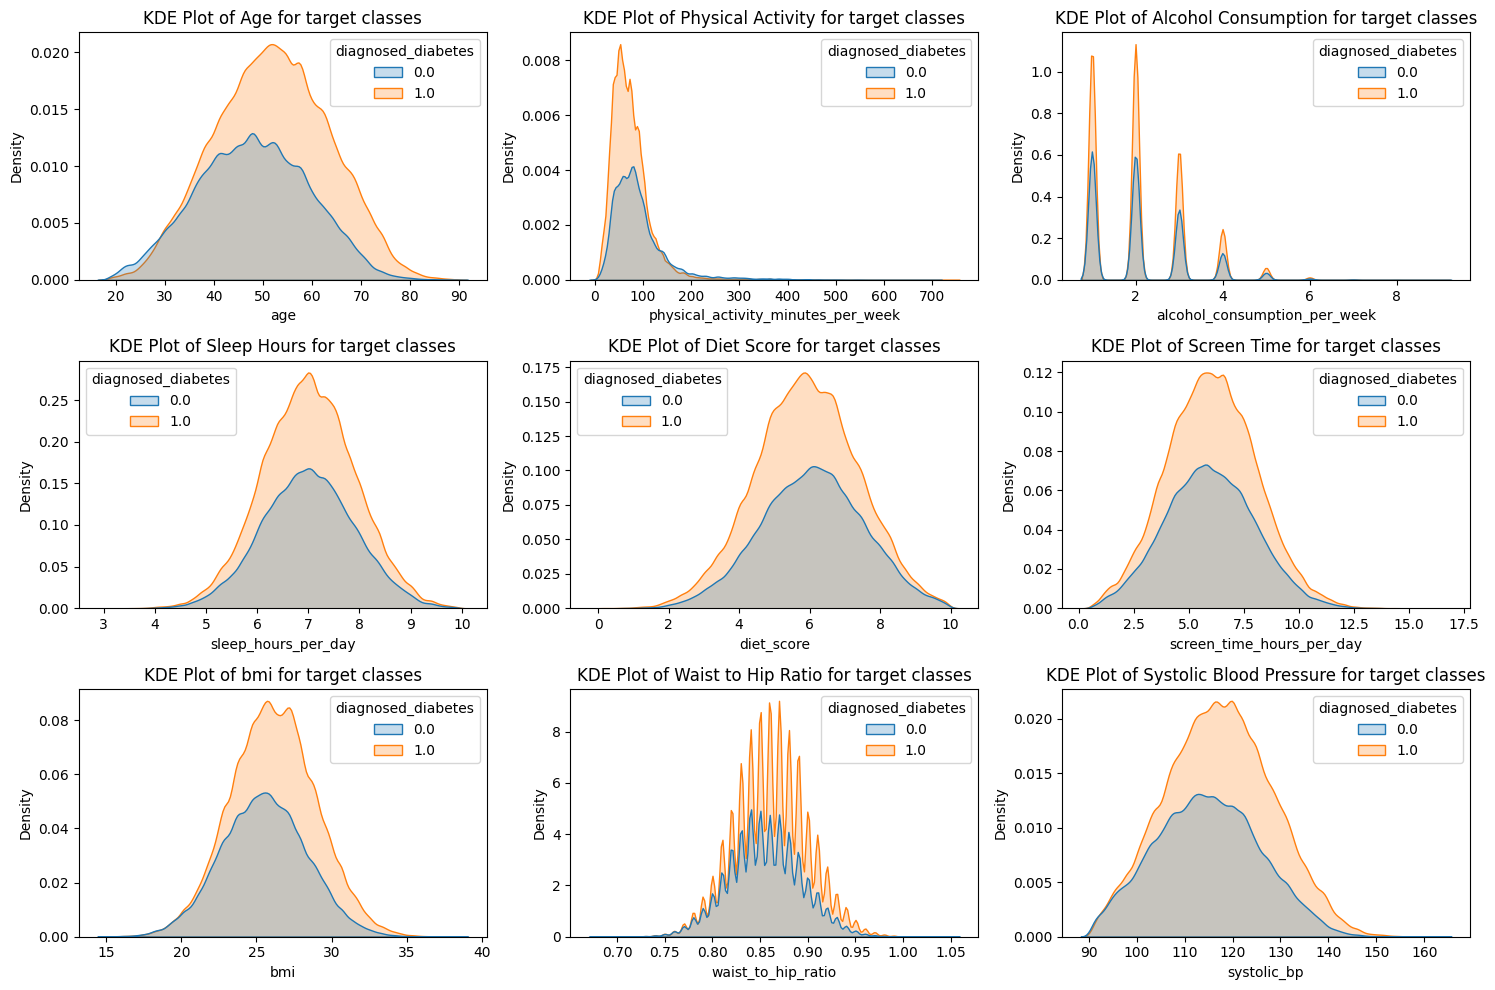

In [22]:
fig,axs = plt.subplots(3,3,figsize = (15,10))
axs = axs.ravel()
sns.kdeplot(data=train,x="age",hue="diagnosed_diabetes",ax=axs[0],fill = True)
axs[0].set_title("KDE Plot of Age for target classes")

sns.kdeplot(data=train,x="physical_activity_minutes_per_week",hue="diagnosed_diabetes",ax=axs[1],fill = True)
axs[1].set_title("KDE Plot of Physical Activity for target classes")

sns.kdeplot(data=train,x="alcohol_consumption_per_week",hue="diagnosed_diabetes",ax=axs[2],fill = True)
axs[2].set_title("KDE Plot of Alcohol Consumption for target classes")


sns.kdeplot(data=train,x="sleep_hours_per_day",hue="diagnosed_diabetes",ax=axs[3],fill = True)
axs[3].set_title("KDE Plot of Sleep Hours for target classes")


sns.kdeplot(data=train,x="diet_score",hue="diagnosed_diabetes",ax=axs[4],fill = True)
axs[4].set_title("KDE Plot of Diet Score for target classes")

sns.kdeplot(data=train,x = "screen_time_hours_per_day",hue="diagnosed_diabetes",ax=axs[5],fill = True)
axs[5].set_title("KDE Plot of Screen Time for target classes")

sns.kdeplot(data=train,x = "bmi",hue="diagnosed_diabetes",ax=axs[6],fill = True)
axs[6].set_title("KDE Plot of bmi for target classes")

sns.kdeplot(data=train,x = "waist_to_hip_ratio",hue="diagnosed_diabetes",ax=axs[7],fill = True)
axs[7].set_title("KDE Plot of Waist to Hip Ratio for target classes")

sns.kdeplot(data=train,x = "systolic_bp",hue="diagnosed_diabetes",ax=axs[8],fill = True)
axs[8].set_title("KDE Plot of Systolic Blood Pressure for target classes")

plt.tight_layout()

Notice that age, systolic Blood Pressure, bmi, and waist-to-hip ratio are all right shifted for the diabetic class. This implies that these variables are probably strong predictors for our model. We can drop sleep hours and screen time, but I'm looking to keep lcohol and physical activity as there may be some interaction terms there. We can look at prevelance heatmaps to see if there are any interactions at play there. 

In [ ]:
train.drop(columns = ["sleep_hours_per_day","screen_time_hours_per_day"],inplace = True)
test.drop(columns = ["sleep_hours_per_day","screen_time_hours_per_day"],inplace = True)

C:\Users\silva\AppData\Local\Temp\ipykernel_26764\387294887.py:19: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  prev = g.pivot_table(index="ybin", columns="xbin", values=target, aggfunc=agg)
C:\Users\silva\AppData\Local\Temp\ipykernel_26764\387294887.py:20: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  counts = g.pivot_table(index="ybin", columns="xbin", values=target, aggfunc="size")


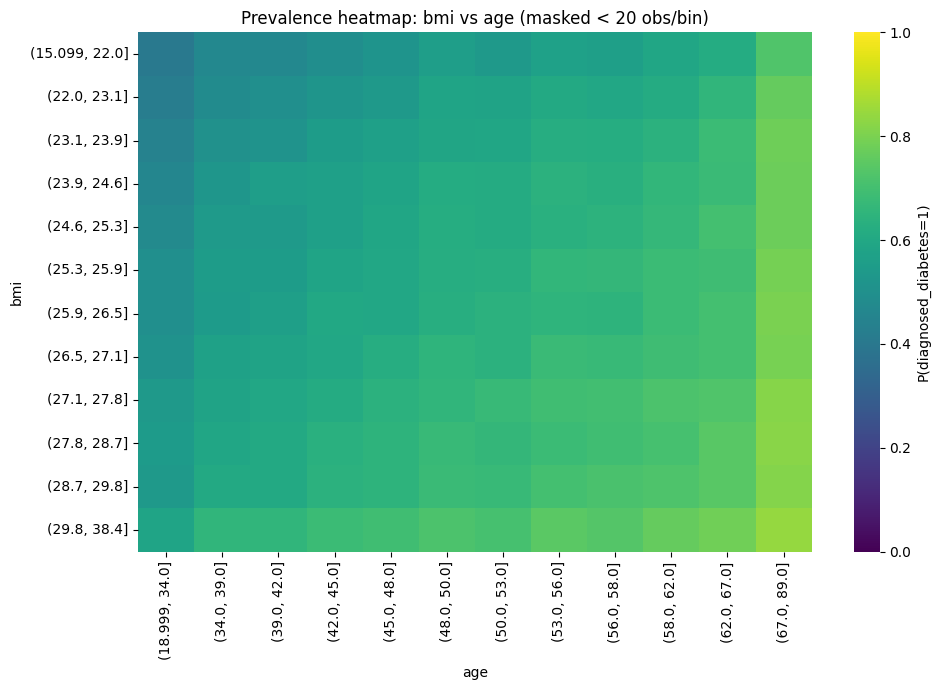

C:\Users\silva\AppData\Local\Temp\ipykernel_26764\387294887.py:19: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  prev = g.pivot_table(index="ybin", columns="xbin", values=target, aggfunc=agg)
C:\Users\silva\AppData\Local\Temp\ipykernel_26764\387294887.py:20: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  counts = g.pivot_table(index="ybin", columns="xbin", values=target, aggfunc="size")


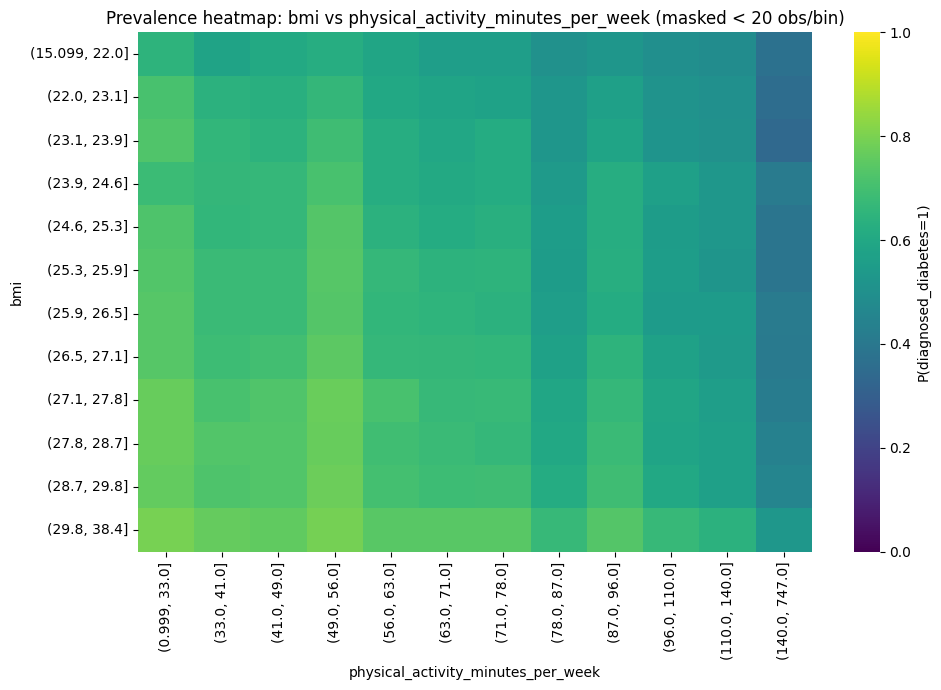

C:\Users\silva\AppData\Local\Temp\ipykernel_26764\387294887.py:19: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  prev = g.pivot_table(index="ybin", columns="xbin", values=target, aggfunc=agg)
C:\Users\silva\AppData\Local\Temp\ipykernel_26764\387294887.py:20: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  counts = g.pivot_table(index="ybin", columns="xbin", values=target, aggfunc="size")


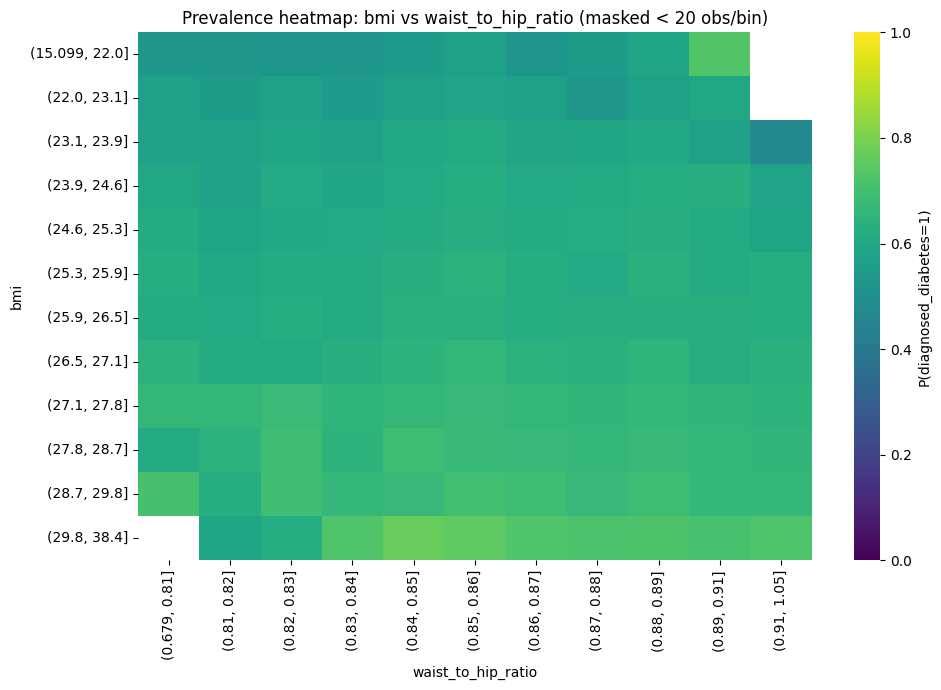

C:\Users\silva\AppData\Local\Temp\ipykernel_26764\387294887.py:19: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  prev = g.pivot_table(index="ybin", columns="xbin", values=target, aggfunc=agg)
C:\Users\silva\AppData\Local\Temp\ipykernel_26764\387294887.py:20: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  counts = g.pivot_table(index="ybin", columns="xbin", values=target, aggfunc="size")


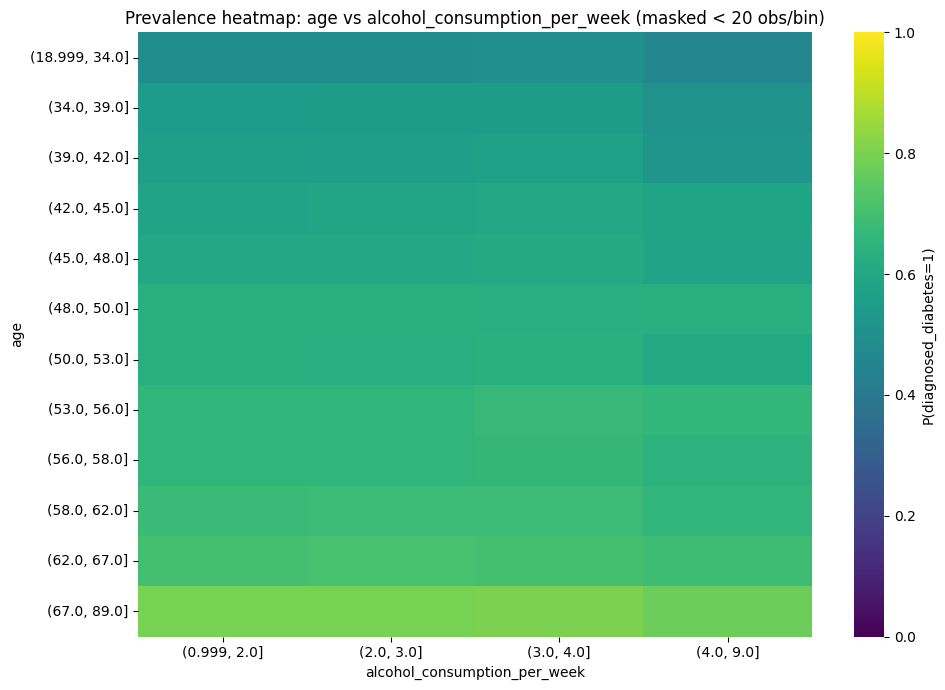

In [29]:
def prevalence_heatmap(
    df, x, y, target="diagnosed_diabetes",
    bins=12, min_count=20, quantile_bins=True,
    agg="mean", cmap="viridis"
):
    d = df[[x, y, target]].dropna().copy()

    
    if quantile_bins:
        xbins = pd.qcut(d[x], q=bins, duplicates="drop")
        ybins = pd.qcut(d[y], q=bins, duplicates="drop")
    else:
        xbins = pd.cut(d[x], bins=bins)
        ybins = pd.cut(d[y], bins=bins)

    g = d.assign(xbin=xbins, ybin=ybins)

   
    prev = g.pivot_table(index="ybin", columns="xbin", values=target, aggfunc=agg)
    counts = g.pivot_table(index="ybin", columns="xbin", values=target, aggfunc="size")

   
    mask = counts < min_count

    plt.figure(figsize=(10, 7))
    ax = sns.heatmap(
        prev, mask=mask, cmap=cmap, vmin=0, vmax=1,
        cbar_kws={"label": f"P({target}=1)"}
    )
    ax.set_title(f"Prevalence heatmap: {y} vs {x} (masked < {min_count} obs/bin)")
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    plt.tight_layout()
    plt.show()


prevalence_heatmap(train, x="age", y="bmi")
prevalence_heatmap(train, x="physical_activity_minutes_per_week", y="bmi")
prevalence_heatmap(train, x="waist_to_hip_ratio", y="bmi")
prevalence_heatmap(train, x = "alcohol_consumption_per_week", y = "age")

These plots can be read from left to right, bottom to top in terms of increasing risk. As we can see, alcohol consumption and age show neglibile interaction. Since age is one of our top predictors, we can drop alcohol consumption. 

In [ ]:
train.drop(columns=["alcohol_consumption_per_week"],inplace = True)
test.drop(columns=["alcohol_consumption_per_week"],inplace = True)

: 

## Data Preprocessing

We need to create a data pipline that scales our data as we will perform regularized logistic regression to sort out our remaining features. Additionally, we want to include interaction terms between our categorical variables and our continuous variables. 